# XQuality Checkpoint-to-Output LLM Ablation — Batched JSONL Robust Version

This notebook evaluates the question:

> Given NeoOLAF's saved checkpoint after Layer X, can a direct LLM finalizer generate the final triples / KG / ontology as well as the native NeoOLAF final output?

This version is designed to avoid the two problems observed in previous runs:

1. **Too many calls**: it batches multiple evidence units per OpenRouter call.
2. **Truncated JSON parse failures**: it asks for JSONL (one JSON object per line) instead of a large JSON array, and salvages all complete triples even if the final line is truncated.

Main features:

- Batched LLM calls: `BATCH_SIZE_UNITS=12` by default, so 226 units become around 19 calls, not 226.
- Parallel OpenRouter calls with `ThreadPoolExecutor`.
- tqdm progress bars for layers and batches.
- JSONL output format for easier partial-output recovery.
- Robust parsing: supports JSONL, JSON arrays, JSON objects with `triples`, and regex salvage.
- Failed/truncated individual generations do not kill the experiment.
- KG and ontology JSON are derived deterministically from predicted triples.
- Same gold evaluation metrics for every layer: entity P/R/F1 and relation P/R/F1.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# ============================================================
# 0. Imports
# ============================================================
import os
import re
import json
import time
import math
import hashlib
import traceback
from pathlib import Path
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
from tqdm.auto import tqdm

try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None

try:
    from litellm import completion
except Exception as e:
    completion = None
    print("LiteLLM is not available yet:", repr(e))

c:\Users\henri\Documents\git\post-doc\neoolafvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
21:16:10 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
21:16:10 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


In [3]:
# ============================================================
# 1. Project root and configuration
# ============================================================

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src" / "neoolaf").exists() or (p / "data" / "XQuality").exists():
            return p
    return start

ROOT = find_root()
print("ROOT =", ROOT)

if load_dotenv is not None:
    for env_path in [ROOT / ".env", ROOT.parent / ".env"]:
        if env_path.exists():
            load_dotenv(env_path)
            print("Loaded .env:", env_path)

# Model / API
MODEL = "openrouter/openai/gpt-oss-20b"
TEMPERATURE = 0.0

# Parallelism
MAX_WORKERS = 4

# Batching: this is the important part.
# 226 units with BATCH_SIZE_UNITS=20 means about 12 calls, not 226.
BATCH_SIZE_UNITS = 12
MAX_BATCH_CHARS = 14000

# Token budget and retry behavior
MAX_TOKENS = 4500
MAX_RETRIES = 2
RETRY_BACKOFF_SECONDS = 3

# JSONL is more robust than one huge JSON array: if output is truncated, complete lines are still usable.
USE_JSONL_OUTPUT = True

# If True, batches with no parseable triples are counted as parse errors.
# Keep False because some evidence units legitimately contain no triples.
STRICT_PARSE_ERRORS = False

# Smoke-test controls
MAX_UNITS_PER_LAYER = None   # Set to 2 or 3 for quick tests
MAX_LAYERS = None            # Set to 1 for a smoke test
FORCE_RERUN = False

# Checkpoint selection
KEEP_LATEST_PER_LAYER = True
STATE_PATH_FILTER = "xquality_machine32"  # set to None to include all state.json files under RUNS_ROOT

# Output
RUNS_ROOT = ROOT / "examples" / "XQualityMachine32" / "runs"
OUTPUT_DIR = RUNS_ROOT / "checkpoint_to_output_llm_ablation_batched_jsonl_robust"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Gold paths
GOLD_JSON = ROOT / "data" / "XQuality" / "Examples" / "XQuality_all_triplets_flat_en.json"
MACHINE32_GOLD_JSON = ROOT / "data" / "XQuality" / "Machine32" / "machine32_triples.json"
GOLD_EXCEL = ROOT / "data" / "XQuality" / "Machine32" / "machine32_triples.xlsx"

print("RUNS_ROOT =", RUNS_ROOT)
print("OUTPUT_DIR =", OUTPUT_DIR)
print("MODEL =", MODEL)
print("MAX_WORKERS =", MAX_WORKERS)
print("BATCH_SIZE_UNITS =", BATCH_SIZE_UNITS)
print("MAX_BATCH_CHARS =", MAX_BATCH_CHARS)

if completion is None:
    print("\\nWARNING: litellm is missing. Install or activate the NeoOLAF environment before running LLM cells.")

if not os.environ.get("OPENROUTER_API_KEY"):
    print("\\nWARNING: OPENROUTER_API_KEY is not set in this environment.")

ROOT = C:\Users\henri\Documents\git\post-doc\NeoOLAF
Loaded .env: C:\Users\henri\Documents\git\post-doc\NeoOLAF\.env
RUNS_ROOT = C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs
OUTPUT_DIR = C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\checkpoint_to_output_llm_ablation_batched_jsonl_robust
MODEL = openrouter/openai/gpt-oss-20b
MAX_WORKERS = 4
BATCH_SIZE_UNITS = 12
MAX_BATCH_CHARS = 14000


In [4]:
# ============================================================
# 2. Robust gold loader
# ============================================================

def _is_empty(x):
    if x is None:
        return True
    try:
        if isinstance(x, float) and pd.isna(x):
            return True
    except Exception:
        pass
    s = str(x).strip()
    return s == "" or s.lower() in {"nan", "none", "null"}

def _clean_label(x):
    if _is_empty(x):
        return ""
    if isinstance(x, dict):
        for k in ["label", "name", "text", "value", "id"]:
            if k in x and not _is_empty(x[k]):
                return _clean_label(x[k])
        return ""
    return re.sub(r"\\s+", " ", str(x).strip())

def _norm_key(k):
    return re.sub(r"[^a-z0-9]+", "", str(k).lower())

def _find_col(columns, candidates):
    norm_to_original = {_norm_key(c): c for c in columns}
    for cand in candidates:
        nc = _norm_key(cand)
        for nk, original in norm_to_original.items():
            if nc == nk or nc in nk or nk in nc:
                return original
    return None

def _canonical_predicate(x):
    if _is_empty(x):
        return ""
    s = str(x).strip().upper()
    s_norm = re.sub(r"[^A-Z0-9]+", "_", s).strip("_")
    aliases = {
        "TRIGGER": "TRIGGERS",
        "TRIGGERS": "TRIGGERS",
        "CAUSE": "CAUSES",
        "CAUSES": "CAUSES",
        "EFFECT": "CAUSES",
        "EFFET": "CAUSES",
        "REQUIRES": "REQUIRES",
        "REQUIRE": "REQUIRES",
        "INTERVENTION": "REQUIRES",
        "ACTION": "REQUIRES",
        "HANDLED_BY": "HANDLED_BY",
        "RESPONSIBLE": "HANDLED_BY",
        "RESPONSABLE": "HANDLED_BY",
        "CHARGE_INTERVENTION": "HANDLED_BY",
        "CHARGE_DE_L_INTERVENTION": "HANDLED_BY",
        "REFERENCES": "REFERENCES",
        "REFERENCE": "REFERENCES",
        "REF": "REFERENCES",
    }
    return aliases.get(s_norm, s_norm)

def _dedup_triples(triples):
    seen = set()
    out = []
    for t in triples:
        subj = _clean_label(t.get("subject_label") or t.get("subject") or t.get("s"))
        pred = _canonical_predicate(t.get("predicate") or t.get("relation") or t.get("p"))
        obj = _clean_label(t.get("object_label") or t.get("object") or t.get("o"))
        if not subj or not pred or not obj:
            continue
        key = (subj.lower(), pred.upper(), obj.lower())
        if key in seen:
            continue
        seen.add(key)
        out.append({
            "triple_id": f"triple_{len(out):05d}",
            "subject_label": subj,
            "predicate": pred,
            "object_label": obj,
            "confidence": float(t.get("confidence", 1.0) or 1.0),
        })
    return out

def _flatten_json_records(obj):
    records = []
    if isinstance(obj, dict):
        keys = {_norm_key(k): k for k in obj.keys()}
        has_subj = any(k in keys for k in ["subject", "subjectlabel", "subj", "source", "head"])
        has_pred = any(k in keys for k in ["predicate", "relation", "pred", "property"])
        has_obj = any(k in keys for k in ["object", "objectlabel", "obj", "target", "tail"])
        if has_subj and has_pred and has_obj:
            records.append(obj)
        for v in obj.values():
            records.extend(_flatten_json_records(v))
    elif isinstance(obj, list):
        for item in obj:
            records.extend(_flatten_json_records(item))
    return records

def _triples_from_json(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    records = _flatten_json_records(data)
    triples = []
    for r in records:
        cols = list(r.keys())
        subj_col = _find_col(cols, ["subject_label", "subject", "subj", "source", "head"])
        pred_col = _find_col(cols, ["predicate", "relation", "pred", "property"])
        obj_col = _find_col(cols, ["object_label", "object", "obj", "target", "tail"])
        if subj_col and pred_col and obj_col:
            triples.append({
                "subject_label": r.get(subj_col),
                "predicate": r.get(pred_col),
                "object_label": r.get(obj_col),
            })
    return triples

def _triples_from_flat_dataframe(df):
    triples = []
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    cols = list(df.columns)
    subj_col = _find_col(cols, ["subject_label", "subject", "subj", "source", "head"])
    pred_col = _find_col(cols, ["predicate", "relation", "pred", "property"])
    obj_col = _find_col(cols, ["object_label", "object", "obj", "target", "tail"])
    if not (subj_col and pred_col and obj_col):
        return []
    for _, row in df.iterrows():
        triples.append({
            "subject_label": row.get(subj_col),
            "predicate": row.get(pred_col),
            "object_label": row.get(obj_col),
        })
    return triples

def _triples_from_structured_dataframe(df):
    triples = []
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    cols = list(df.columns)
    alarm_col = _find_col(cols, ["alarm", "message", "texte", "text", "label", "libelle", "libellé", "alarme", "nom", "title"])
    cause_col = _find_col(cols, ["cause", "trigger", "triggers", "déclenche", "declenche"])
    effect_col = _find_col(cols, ["effect", "effet", "consequence", "conséquence"])
    intervention_col = _find_col(cols, ["intervention", "action", "requires", "requirement", "solution", "remedy", "correction"])
    responsible_col = _find_col(cols, ["responsible", "responsable", "actor", "operator", "opérateur", "charge", "chargé", "intervenant"])
    reference_col = _find_col(cols, ["reference", "référence", "ref", "page", "input", "schema", "electrical"])
    for _, row in df.iterrows():
        alarm = _clean_label(row.get(alarm_col)) if alarm_col else ""
        if not alarm:
            continue
        if cause_col:
            cause = _clean_label(row.get(cause_col))
            if cause:
                triples.append({"subject_label": cause, "predicate": "TRIGGERS", "object_label": alarm})
        if effect_col:
            effect = _clean_label(row.get(effect_col))
            if effect:
                triples.append({"subject_label": alarm, "predicate": "CAUSES", "object_label": effect})
        if intervention_col:
            intervention = _clean_label(row.get(intervention_col))
            if intervention:
                triples.append({"subject_label": alarm, "predicate": "REQUIRES", "object_label": intervention})
        if responsible_col:
            responsible = _clean_label(row.get(responsible_col))
            if responsible:
                actors = re.split(r"\\s*(?:;|/|\\bet\\b|\\band\\b)\\s*", responsible)
                for actor in actors:
                    actor = _clean_label(actor)
                    if actor:
                        triples.append({"subject_label": alarm, "predicate": "HANDLED_BY", "object_label": actor})
        if reference_col:
            ref = _clean_label(row.get(reference_col))
            if ref:
                triples.append({"subject_label": alarm, "predicate": "REFERENCES", "object_label": ref})
    return triples

def _triples_from_excel(path):
    triples = []
    xls = pd.ExcelFile(path)
    print(f"Excel sheets in {path.name}: {xls.sheet_names}")
    for sheet_name in xls.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet_name)
        print(f"  Sheet {sheet_name}: shape={df.shape}; columns={list(df.columns)}")
        triples.extend(_triples_from_flat_dataframe(df))
        triples.extend(_triples_from_structured_dataframe(df))
    return triples

def load_gold_triples():
    triples = []
    print("Checking gold JSON candidates:")
    for path in [GOLD_JSON, MACHINE32_GOLD_JSON]:
        print(f" - {path} | exists={path.exists()}")
        if path.exists():
            try:
                loaded = _triples_from_json(path)
                print(f"   loaded JSON triples: {len(loaded)}")
                triples.extend(loaded)
            except Exception as e:
                print("   JSON load failed:", repr(e))
    print("\\nChecking gold Excel candidates:")
    for path in [GOLD_EXCEL]:
        print(f" - {path} | exists={path.exists()}")
        if path.exists():
            try:
                loaded = _triples_from_excel(path)
                print(f"   loaded Excel triples: {len(loaded)}")
                triples.extend(loaded)
            except Exception as e:
                print("   Excel load failed:", repr(e))
    triples = _dedup_triples(triples)
    if not triples:
        raise RuntimeError("Could not load gold triples. Files exist, but their schema was not recognized.")
    return triples

gold_triples = load_gold_triples()
print("\\nGold triples:", len(gold_triples))
print("Gold predicates:", Counter(t["predicate"] for t in gold_triples))
pd.DataFrame(gold_triples).head()

Checking gold JSON candidates:
 - C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Examples\XQuality_all_triplets_flat_en.json | exists=True
   loaded JSON triples: 0
 - C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\machine32_triples.json | exists=True
   loaded JSON triples: 0
\nChecking gold Excel candidates:
 - C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\machine32_triples.xlsx | exists=True
Excel sheets in machine32_triples.xlsx: ['Triplets Graphe', 'Légende']
  Sheet Triplets Graphe: shape=(439, 7); columns=['#', 'Nœud 1', 'RELATION', 'Nœud 2', 'Type Triplet', 'N° Alarme', 'Catégorie']
  Sheet Légende: shape=(15, 4); columns=['LÉGENDE — Graphe de Connaissance Enrichi', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']
   loaded Excel triples: 2634
\nGold triples: 2634
Gold predicates: Counter({'TRIGGERS': 439, 'CAUSES': 439, 'REQUIRES': 439, 'HANDLED_BY': 439, 'REFERENCES': 439, '1': 1, '2': 1, '3': 1, '4': 1, '5': 1, '6': 1, '7'

,triple_id,subject_label,predicate,object_label,confidence
0,triple_00000,1,1,1,1.0
1,triple_00001,2,2,2,1.0
2,triple_00002,3,3,3,1.0
3,triple_00003,4,4,4,1.0
4,triple_00004,5,5,5,1.0


In [5]:
# ============================================================
# 3. Evaluation helpers
# ============================================================

def norm_text(x):
    s = _clean_label(x).lower()
    s = re.sub(r"[^a-z0-9à-ÿ]+", " ", s)
    s = re.sub(r"\\s+", " ", s).strip()
    return s

def triple_key(t):
    return (
        norm_text(t.get("subject_label")),
        _canonical_predicate(t.get("predicate")),
        norm_text(t.get("object_label")),
    )

def evaluate_triples(pred_triples, gold_triples):
    pred = _dedup_triples(pred_triples)
    gold = _dedup_triples(gold_triples)

    pred_set = {triple_key(t) for t in pred}
    gold_set = {triple_key(t) for t in gold}

    pred_entities = {norm_text(t["subject_label"]) for t in pred} | {norm_text(t["object_label"]) for t in pred}
    gold_entities = {norm_text(t["subject_label"]) for t in gold} | {norm_text(t["object_label"]) for t in gold}

    def prf(pred_items, gold_items):
        tp = len(pred_items & gold_items)
        fp = len(pred_items - gold_items)
        fn = len(gold_items - pred_items)
        p = tp / (tp + fp) if (tp + fp) else 0.0
        r = tp / (tp + fn) if (tp + fn) else 0.0
        f = 2 * p * r / (p + r) if (p + r) else 0.0
        return {"precision": p, "recall": r, "f1": f, "tp": tp, "fp": fp, "fn": fn}

    entity_metrics = prf(pred_entities, gold_entities)
    relation_metrics = prf(pred_set, gold_set)

    per_relation = {}
    predicates = sorted({t["predicate"] for t in gold} | {t["predicate"] for t in pred})
    for rel in predicates:
        ps = {triple_key(t) for t in pred if t["predicate"] == rel}
        gs = {triple_key(t) for t in gold if t["predicate"] == rel}
        per_relation[rel] = prf(ps, gs)
        per_relation[rel]["pred_count"] = len(ps)
        per_relation[rel]["gold_count"] = len(gs)

    return {
        "entity": entity_metrics,
        "relation": relation_metrics,
        "per_relation": per_relation,
        "counts": {
            "pred_triples": len(pred_set),
            "gold_triples": len(gold_set),
            "pred_entities": len(pred_entities),
            "gold_entities": len(gold_entities),
        }
    }

def derive_kg_and_ontology(triples):
    triples = _dedup_triples(triples)
    nodes = {}
    edges = []

    for t in triples:
        s = _clean_label(t["subject_label"])
        o = _clean_label(t["object_label"])
        p = _canonical_predicate(t["predicate"])
        sid = hashlib.sha1(s.lower().encode("utf-8")).hexdigest()[:12]
        oid = hashlib.sha1(o.lower().encode("utf-8")).hexdigest()[:12]
        nodes[sid] = {"id": sid, "label": s}
        nodes[oid] = {"id": oid, "label": o}
        edges.append({
            "source": sid,
            "target": oid,
            "predicate": p,
            "subject_label": s,
            "object_label": o,
            "confidence": float(t.get("confidence", 1.0) or 1.0),
        })

    kg = {"nodes": list(nodes.values()), "edges": edges}

    ontology = {
        "classes": sorted({n["label"] for n in nodes.values()}),
        "object_properties": sorted({e["predicate"] for e in edges}),
        "relation_profile": {
            "TRIGGERS": "cause/explanation -> alarm/message",
            "CAUSES": "alarm/message -> effect/consequence",
            "REQUIRES": "alarm/message -> intervention/action",
            "HANDLED_BY": "alarm/message -> responsible actor",
            "REFERENCES": "alarm/message -> technical reference",
        }
    }

    return kg, ontology

In [6]:
# ============================================================
# 4. Discover saved checkpoints
# ============================================================

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def layer_name_from_state(state, path):
    for key_path in [
        ("metadata", "layer"),
        ("metadata", "layer_name"),
        ("layer",),
        ("layer_name",),
        ("config", "layer"),
    ]:
        cur = state
        ok = True
        for k in key_path:
            if isinstance(cur, dict) and k in cur:
                cur = cur[k]
            else:
                ok = False
                break
        if ok and cur:
            return str(cur)
    for part in reversed(path.parts):
        if re.search(r"layer\\d+", part, re.I):
            return part
    return path.parent.name

def layer_sort_key(name):
    m = re.search(r"layer\\s*_?(\\d+)", str(name), re.I)
    if m:
        return int(m.group(1))
    m = re.search(r"(\\d+)", str(name))
    if m:
        return int(m.group(1))
    return 999

def discover_states():
    paths = sorted(RUNS_ROOT.rglob("state.json"))
    if STATE_PATH_FILTER:
        paths = [p for p in paths if STATE_PATH_FILTER.lower() in str(p).lower()]

    rows = []
    for p in paths:
        try:
            st = load_json(p)
            layer = layer_name_from_state(st, p)
            rows.append({
                "layer": layer,
                "layer_sort": layer_sort_key(layer),
                "state_path": p,
                "mtime": p.stat().st_mtime,
                "size_mb": p.stat().st_size / 1e6,
            })
        except Exception as e:
            print("Skipping state due to error:", p, repr(e))

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No state.json found under {RUNS_ROOT} with filter {STATE_PATH_FILTER!r}")

    if KEEP_LATEST_PER_LAYER:
        df = (
            df.sort_values(["layer_sort", "mtime"], ascending=[True, False])
              .drop_duplicates(subset=["layer"], keep="first")
              .sort_values(["layer_sort", "layer"])
              .reset_index(drop=True)
        )
    else:
        df = df.sort_values(["layer_sort", "mtime"]).reset_index(drop=True)

    if MAX_LAYERS is not None:
        df = df.head(MAX_LAYERS).copy()

    return df

states_df = discover_states()
print("Discovered checkpoints:", len(states_df))
display(states_df[["layer", "state_path", "size_mb"]])

Discovered checkpoints: 13


,layer,state_path,size_mb
0,layer00_preprocessing,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,2.123968
1,layer01_linguistic_expression_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,3.114100
2,layer02_candidate_enrichment,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,4.194848
3,layer03_candidate_typing_resolution,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,4.839522
4,layer04_candidate_relation_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,5.174644
5,layer05_candidate_triple_generation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,5.817872
6,layer06_concept_relation_induction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,6.270324
7,layer07_hierarchisation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,6.646620
8,layer08_axiom_schemata_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,7.104622
9,layer09_general_axiom_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,8.067089


In [7]:
# ============================================================
# 5. Extract compact evidence units from a checkpoint
# ============================================================

PREFERRED_LIST_KEYS = [
    "alarm_records",
    "chunks",
    "linguistic_expressions",
    "enriched_expressions",
    "entity_candidates",
    "relation_candidates",
    "event_candidates",
    "candidate_relation_assertions",
    "candidate_triples",
    "concept_candidates",
    "ontology_relation_candidates",
    "concept_hierarchy_links",
    "relation_hierarchy_links",
    "axiom_schema_candidates",
    "general_axiom_candidates",
    "completion_candidates",
    "reasoning_inferred_triples",
]

def compact_obj(obj, max_chars=1400):
    try:
        txt = json.dumps(obj, ensure_ascii=False, default=str)
    except Exception:
        txt = str(obj)
    txt = re.sub(r"\\s+", " ", txt).strip()
    if len(txt) > max_chars:
        return txt[:max_chars] + " ..."
    return txt

def find_preferred_lists(obj, prefix=""):
    found = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            path = f"{prefix}.{k}" if prefix else k
            if k in PREFERRED_LIST_KEYS and isinstance(v, list) and v:
                found.append((path, k, v))
            found.extend(find_preferred_lists(v, path))
    elif isinstance(obj, list):
        for i, item in enumerate(obj[:5]):
            found.extend(find_preferred_lists(item, f"{prefix}[{i}]"))
    return found

def choose_best_lists(found):
    if not found:
        return []
    priority = {k: i for i, k in enumerate(PREFERRED_LIST_KEYS)}
    found = sorted(found, key=lambda x: priority.get(x[1], 999))
    by_key = {}
    for path, key, lst in found:
        if key not in by_key or len(lst) > len(by_key[key][2]):
            by_key[key] = (path, key, lst)
    return list(by_key.values())

def extract_units_from_state(state, layer_name):
    found = choose_best_lists(find_preferred_lists(state))
    units = []

    for path, key, lst in found:
        for i, item in enumerate(lst):
            units.append({
                "unit_id": f"{key}_{i:05d}",
                "unit_type": key,
                "source_path": path,
                "text": compact_obj(item),
            })

    if not units:
        units = [{
            "unit_id": "whole_state_00000",
            "unit_type": "whole_state",
            "source_path": "state",
            "text": compact_obj(state, max_chars=MAX_BATCH_CHARS),
        }]

    seen = set()
    deduped = []
    for u in units:
        key = (u["unit_type"], u["text"])
        if key in seen:
            continue
        seen.add(key)
        deduped.append(u)

    if MAX_UNITS_PER_LAYER is not None:
        deduped = deduped[:MAX_UNITS_PER_LAYER]

    return deduped

def make_batches(units, batch_size=BATCH_SIZE_UNITS, max_chars=MAX_BATCH_CHARS):
    batches = []
    cur = []
    cur_chars = 0

    for u in units:
        u_chars = len(u["text"])
        if cur and (len(cur) >= batch_size or cur_chars + u_chars > max_chars):
            batches.append(cur)
            cur = []
            cur_chars = 0
        cur.append(u)
        cur_chars += u_chars

    if cur:
        batches.append(cur)

    return batches

preview_rows = []
for _, row in states_df.iterrows():
    st = load_json(row["state_path"])
    units = extract_units_from_state(st, row["layer"])
    batches = make_batches(units)
    preview_rows.append({
        "layer": row["layer"],
        "units": len(units),
        "estimated_llm_calls": len(batches),
        "batch_size_units": BATCH_SIZE_UNITS,
        "max_batch_chars": MAX_BATCH_CHARS,
    })

preview_df = pd.DataFrame(preview_rows)
display(preview_df)
print("Estimated total LLM calls:", int(preview_df["estimated_llm_calls"].sum()))

,layer,units,estimated_llm_calls,batch_size_units,max_batch_chars
0,layer00_preprocessing,83,10,12,14000
1,layer01_linguistic_expression_extraction,476,45,12,14000
2,layer02_candidate_enrichment,786,79,12,14000
3,layer03_candidate_typing_resolution,1095,112,12,14000
4,layer04_candidate_relation_extraction,1321,132,12,14000
5,layer05_candidate_triple_generation,1547,157,12,14000
6,layer06_concept_relation_induction,1856,185,12,14000
7,layer07_hierarchisation,2165,210,12,14000
8,layer08_axiom_schemata_extraction,2484,238,12,14000
9,layer09_general_axiom_extraction,3112,297,12,14000


Estimated total LLM calls: 3024


## Optional smoke-test mode

Uncomment the next cell if you want to test only one layer and two units before launching the full run.

In [8]:
# # ============================================================
# # Smoke test: uncomment this cell for a tiny run
# # ============================================================
# MAX_UNITS_PER_LAYER = 2
# MAX_WORKERS = 2
# FORCE_RERUN = True
# states_df = states_df.head(1).copy()
# display(states_df)

In [9]:
# ============================================================
# 6. LLM finalizer: batched prompt, JSONL output, robust parse/salvage
# ============================================================

RELATION_PROFILE = """
XQuality relation profile:
- TRIGGERS: cause/explanation -> alarm/message.
- CAUSES: alarm/message -> effect/consequence.
- REQUIRES: alarm/message -> intervention/action.
- HANDLED_BY: alarm/message -> responsible actor.
- REFERENCES: alarm/message -> technical reference/page/input/schema.

Use only these predicates:
TRIGGERS, CAUSES, REQUIRES, HANDLED_BY, REFERENCES.
"""

JSONL_SCHEMA = """
Return one JSON object per line, with this exact schema:
{"unit_id":"string","subject_label":"string","predicate":"TRIGGERS|CAUSES|REQUIRES|HANDLED_BY|REFERENCES","object_label":"string","confidence":0.0}

If no triple is supported by the evidence, return exactly:
NO_TRIPLES
"""

def batch_prompt(layer_name, batch_units):
    units_text = []
    for u in batch_units:
        units_text.append(
            f"UNIT_ID: {u['unit_id']}\n"
            f"UNIT_TYPE: {u['unit_type']}\n"
            f"SOURCE_PATH: {u['source_path']}\n"
            f"CONTENT: {u['text']}"
        )
    units_blob = "\n\n---\n\n".join(units_text)

    return f"""
You are evaluating an intermediate NeoOLAF checkpoint for the XQuality Machine32 document.

Task:
From the evidence units below, generate final extraction triples for the XQuality graph.

{RELATION_PROFILE}

Rules:
- Use only information supported by the evidence units.
- Do not invent alarms, causes, effects, interventions, actors, references, pages, or inputs.
- It is acceptable to output no triples if a unit does not contain enough information.
- Keep labels concise but faithful.
- Prefer English labels when the evidence is already translated, but preserve technical alarm labels.
- Do not include markdown.
- Do not include explanations.
- Do not wrap the output in a top-level JSON object.
- Do not output a JSON array.
- Output JSONL only: one complete JSON object per line.

{JSONL_SCHEMA}

Checkpoint layer: {layer_name}

Evidence units:
{units_blob}
""".strip()

def _strip_code_fences(text):
    raw = str(text or "").strip()
    raw = re.sub(r"^```(?:json|jsonl)?\s*", "", raw, flags=re.I)
    raw = re.sub(r"\s*```$", "", raw).strip()
    return raw

def _iter_balanced_json_objects(raw):
    """Yield balanced {...} substrings while respecting quoted strings."""
    s = str(raw or "")
    start = None
    depth = 0
    in_str = False
    esc = False
    for i, ch in enumerate(s):
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
            continue
        if ch == '"':
            in_str = True
        elif ch == "{":
            if depth == 0:
                start = i
            depth += 1
        elif ch == "}":
            if depth > 0:
                depth -= 1
                if depth == 0 and start is not None:
                    yield s[start:i+1]
                    start = None

def _coerce_payload_to_triples(payload):
    """Convert supported payload shapes into triples."""
    if isinstance(payload, list):
        triples = []
        for item in payload:
            triples.extend(_coerce_payload_to_triples(item))
        return _dedup_triples(triples)

    if isinstance(payload, dict):
        if isinstance(payload.get("triples"), list):
            return _dedup_triples(payload["triples"])
        maybe = _dedup_triples([payload])
        return maybe

    return []

def parse_triples_from_llm_text(text):
    """
    Robust parser for LLM output.

    Supports:
    1. JSONL: one JSON object per line.
    2. Full JSON object: {"triples": [...]}.
    3. Full JSON array: [{...}, {...}].
    4. Salvage of all balanced JSON objects inside a truncated response.

    If the model truncates the last line, all previous complete lines are still used.
    """
    raw = _strip_code_fences(text)
    if not raw:
        return [], "empty_response"

    # Explicit no-output marker.
    if raw.strip().upper() == "NO_TRIPLES":
        return [], None

    triples = []
    warnings = []

    # 1) Try complete JSON first.
    try:
        payload = json.loads(raw)
        triples = _coerce_payload_to_triples(payload)
        return triples, None
    except Exception as e:
        warnings.append(f"full_json_failed={type(e).__name__}")

    # 2) JSONL line-by-line. Ignore truncated/incomplete lines.
    line_triples = []
    bad_lines = 0
    for line in raw.splitlines():
        line = line.strip().rstrip(",")
        if not line or line.upper() == "NO_TRIPLES":
            continue
        if not (line.startswith("{") and line.endswith("}")):
            # likely a truncated last line or extra text
            if line.startswith("{") or "subject_label" in line:
                bad_lines += 1
            continue
        try:
            obj = json.loads(line)
            line_triples.extend(_coerce_payload_to_triples(obj))
        except Exception:
            bad_lines += 1
    if line_triples:
        warning = None if bad_lines == 0 else f"jsonl_salvaged_with_{bad_lines}_bad_lines"
        return _dedup_triples(line_triples), warning

    # 3) Balanced object salvage anywhere in text.
    object_triples = []
    for frag in _iter_balanced_json_objects(raw):
        if "subject_label" not in frag or "predicate" not in frag or "object_label" not in frag:
            continue
        try:
            obj = json.loads(frag)
            object_triples.extend(_coerce_payload_to_triples(obj))
        except Exception:
            continue
    if object_triples:
        return _dedup_triples(object_triples), "balanced_object_salvage"

    # 4) Regex fallback for field triples. This ignores incomplete final triples.
    regex_triples = []
    pattern = re.compile(
        r'"subject_label"\s*:\s*"(?P<s>(?:[^"\\]|\\.)*)".*?'
        r'"predicate"\s*:\s*"(?P<p>TRIGGERS|CAUSES|REQUIRES|HANDLED_BY|REFERENCES)".*?'
        r'"object_label"\s*:\s*"(?P<o>(?:[^"\\]|\\.)*)"',
        flags=re.I | re.S,
    )
    for m in pattern.finditer(raw):
        def unescape(x):
            try:
                return json.loads('"' + x + '"')
            except Exception:
                return x
        regex_triples.append({
            "subject_label": unescape(m.group("s")),
            "predicate": m.group("p").upper(),
            "object_label": unescape(m.group("o")),
            "confidence": 0.0,
        })
    if regex_triples:
        return _dedup_triples(regex_triples), "regex_field_salvage"

    if STRICT_PARSE_ERRORS:
        return [], ";".join(warnings) or "could_not_parse"
    return [], None

def call_llm_batch(layer_name, batch_units, batch_index, max_tokens=MAX_TOKENS):
    if completion is None:
        raise RuntimeError("litellm.completion is unavailable. Activate the NeoOLAF environment.")

    prompt = batch_prompt(layer_name, batch_units)
    messages = [
        {"role": "system", "content": "You are a strict information extraction system. Return JSONL only, one JSON object per line, or NO_TRIPLES."},
        {"role": "user", "content": prompt},
    ]

    last_error = None
    raw = None
    best_triples = []
    best_warning = None

    for attempt in range(MAX_RETRIES + 1):
        try:
            response = completion(
                model=MODEL,
                messages=messages,
                temperature=TEMPERATURE,
                max_tokens=max_tokens + attempt * 1500,
            )
            raw = response.choices[0].message.content
            triples, warning = parse_triples_from_llm_text(raw)

            if triples:
                return {
                    "batch_index": batch_index,
                    "ok": True,
                    "triples": triples,
                    "raw_response": raw,
                    "parse_error": None,
                    "parse_warning": warning,
                    "salvaged": warning is not None,
                    "attempts": attempt + 1,
                    "unit_count": len(batch_units),
                }

            # No triples can be legitimate. Do not retry forever unless strict mode says it is a parse problem.
            if warning is None:
                return {
                    "batch_index": batch_index,
                    "ok": True,
                    "triples": [],
                    "raw_response": raw,
                    "parse_error": None,
                    "parse_warning": None,
                    "salvaged": False,
                    "attempts": attempt + 1,
                    "unit_count": len(batch_units),
                }

            best_warning = warning
            last_error = ValueError(warning)

        except Exception as e:
            last_error = e
            triples, warning = parse_triples_from_llm_text(raw)
            if triples:
                return {
                    "batch_index": batch_index,
                    "ok": True,
                    "triples": triples,
                    "raw_response": raw,
                    "parse_error": None,
                    "parse_warning": warning or repr(e),
                    "salvaged": True,
                    "attempts": attempt + 1,
                    "unit_count": len(batch_units),
                }

        if attempt < MAX_RETRIES:
            time.sleep(RETRY_BACKOFF_SECONDS * (attempt + 1))

    # Final fallback. In non-strict mode this is not an error, just a zero-triple batch.
    return {
        "batch_index": batch_index,
        "ok": not STRICT_PARSE_ERRORS,
        "triples": best_triples,
        "raw_response": raw,
        "parse_error": repr(last_error) if STRICT_PARSE_ERRORS else None,
        "parse_warning": best_warning or (repr(last_error) if last_error else None),
        "salvaged": False,
        "attempts": MAX_RETRIES + 1,
        "unit_count": len(batch_units),
    }


In [10]:
# ============================================================
# 7. Native NeoOLAF triple extraction for final baseline
# ============================================================

def get_nested(d, paths):
    for path in paths:
        cur = d
        ok = True
        for k in path:
            if isinstance(cur, dict) and k in cur:
                cur = cur[k]
            else:
                ok = False
                break
        if ok and not _is_empty(cur):
            return cur
    return None

def parse_any_triple_record(r):
    if not isinstance(r, dict):
        return None

    subj = get_nested(r, [
        ("subject_label",), ("subject", "label"), ("subject", "name"), ("subject",),
        ("source_label",), ("source", "label"), ("head", "label"), ("head",)
    ])
    pred = get_nested(r, [
        ("predicate",), ("relation",), ("relation_type",), ("property",), ("p",)
    ])
    obj = get_nested(r, [
        ("object_label",), ("object", "label"), ("object", "name"), ("object",),
        ("target_label",), ("target", "label"), ("tail", "label"), ("tail",)
    ])

    if _is_empty(subj) or _is_empty(pred) or _is_empty(obj):
        return None

    return {
        "subject_label": _clean_label(subj),
        "predicate": _canonical_predicate(pred),
        "object_label": _clean_label(obj),
        "confidence": float(r.get("confidence", 1.0) or 1.0) if isinstance(r, dict) else 1.0,
    }

def extract_native_triples_from_state(state):
    triples = []
    for key in ["reasoning_inferred_triples", "candidate_triples", "candidate_relation_assertions", "relation_candidates"]:
        if isinstance(state, dict) and isinstance(state.get(key), list):
            for r in state[key]:
                t = parse_any_triple_record(r)
                if t:
                    triples.append(t)
    if not triples:
        for path, key, lst in find_preferred_lists(state):
            if key in ["reasoning_inferred_triples", "candidate_triples", "candidate_relation_assertions", "relation_candidates"]:
                for r in lst:
                    t = parse_any_triple_record(r)
                    if t:
                        triples.append(t)
    return _dedup_triples(triples)

In [11]:
# ============================================================
# 8. Main batched ablation loop
# ============================================================

status_path = OUTPUT_DIR / "run_status.csv"
progress_log_path = OUTPUT_DIR / "progress.log"

all_summary_rows = []
all_per_relation_rows = []

def log(msg):
    print(msg)
    with open(progress_log_path, "a", encoding="utf-8") as f:
        f.write(str(msg) + "\\n")

layer_iter = tqdm(states_df.itertuples(index=False), total=len(states_df), desc="Checkpoint layers")

for layer_idx, row in enumerate(layer_iter, start=1):
    layer_name = row.layer
    state_path = Path(row.state_path)
    safe_layer_name = re.sub(r"[^a-zA-Z0-9_\\-]+", "_", str(layer_name))
    layer_out = OUTPUT_DIR / safe_layer_name
    layer_out.mkdir(parents=True, exist_ok=True)

    triples_path = layer_out / "llm_triples.json"
    kg_path = layer_out / "kg.json"
    ontology_path = layer_out / "ontology.json"
    metrics_path = layer_out / "metrics.json"
    batch_meta_path = layer_out / "batch_metadata.csv"

    log(f"\\n[{layer_idx}/{len(states_df)}] Layer: {layer_name}")
    log(f"State: {state_path}")

    if triples_path.exists() and metrics_path.exists() and not FORCE_RERUN:
        log("Already completed. Loading cached outputs.")
        pred_triples = load_json(triples_path)
        metrics = load_json(metrics_path)
        batch_meta = pd.read_csv(batch_meta_path).to_dict("records") if batch_meta_path.exists() else []
    else:
        state = load_json(state_path)
        units = extract_units_from_state(state, layer_name)
        batches = make_batches(units)

        log(f"Units: {len(units)}")
        log(f"Batches / LLM calls: {len(batches)}")
        log(f"Max workers: {MAX_WORKERS}")

        pred_triples = []
        batch_meta = []
        t0 = time.time()

        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = {
                executor.submit(call_llm_batch, layer_name, batch, i): i
                for i, batch in enumerate(batches)
            }

            prog = tqdm(as_completed(futures), total=len(futures), desc=f"{layer_name} LLM batches")

            for fut in prog:
                i = futures[fut]
                try:
                    result = fut.result()
                except Exception as e:
                    result = {
                        "batch_index": i,
                        "ok": False,
                        "triples": [],
                        "raw_response": None,
                        "parse_error": repr(e),
                        "salvaged": False,
                        "attempts": 0,
                        "unit_count": len(batches[i]),
                    }

                pred_triples.extend(result.get("triples", []))
                batch_meta.append({
                    "batch_index": result.get("batch_index"),
                    "ok": result.get("ok"),
                    "triple_count": len(result.get("triples", [])),
                    "parse_error": result.get("parse_error"),
                    "parse_warning": result.get("parse_warning"),
                    "salvaged": result.get("salvaged"),
                    "attempts": result.get("attempts"),
                    "unit_count": result.get("unit_count"),
                })

                if result.get("parse_error"):
                    log(f"[ERROR] {layer_name} batch {i}: {str(result.get('parse_error'))[:250]}")
                elif result.get("parse_warning"):
                    log(f"[SALVAGED] {layer_name} batch {i}: {str(result.get('parse_warning'))[:250]}")

                prog.set_postfix({
                    "triples": len(pred_triples),
                    "errors": sum(1 for b in batch_meta if b.get("parse_error")),
                })

        pred_triples = _dedup_triples(pred_triples)
        kg, ontology = derive_kg_and_ontology(pred_triples)
        metrics = evaluate_triples(pred_triples, gold_triples)
        elapsed = time.time() - t0

        with open(triples_path, "w", encoding="utf-8") as f:
            json.dump(pred_triples, f, ensure_ascii=False, indent=2)
        with open(kg_path, "w", encoding="utf-8") as f:
            json.dump(kg, f, ensure_ascii=False, indent=2)
        with open(ontology_path, "w", encoding="utf-8") as f:
            json.dump(ontology, f, ensure_ascii=False, indent=2)

        metrics["runtime_seconds"] = elapsed
        metrics["llm_batches"] = len(batches)
        metrics["units"] = len(units)
        metrics["parse_error_batches"] = sum(1 for b in batch_meta if b.get("parse_error"))
        metrics["salvaged_batches"] = sum(1 for b in batch_meta if b.get("salvaged"))

        with open(metrics_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, ensure_ascii=False, indent=2)
        pd.DataFrame(batch_meta).to_csv(batch_meta_path, index=False)

    summary = {
        "method": "LLM finalizer from checkpoint",
        "layer": layer_name,
        "state_path": str(state_path),
        "pred_triples": metrics["counts"]["pred_triples"],
        "entity_precision": metrics["entity"]["precision"],
        "entity_recall": metrics["entity"]["recall"],
        "entity_f1": metrics["entity"]["f1"],
        "relation_precision": metrics["relation"]["precision"],
        "relation_recall": metrics["relation"]["recall"],
        "relation_f1": metrics["relation"]["f1"],
        "runtime_seconds": metrics.get("runtime_seconds"),
        "units": metrics.get("units"),
        "llm_batches": metrics.get("llm_batches"),
        "parse_error_batches": metrics.get("parse_error_batches"),
        "salvaged_batches": metrics.get("salvaged_batches"),
    }
    all_summary_rows.append(summary)

    for rel, m in metrics["per_relation"].items():
        rr = {"layer": layer_name, "predicate": rel}
        rr.update(m)
        all_per_relation_rows.append(rr)

    pd.DataFrame(all_summary_rows).to_csv(OUTPUT_DIR / "summary_incremental.csv", index=False)
    pd.DataFrame(all_per_relation_rows).to_csv(OUTPUT_DIR / "per_relation_incremental.csv", index=False)
    display(pd.DataFrame([summary]))

print("\\nDone.")

Checkpoint layers:   0%|          | 0/13 [00:00<?, ?it/s]

\n[1/13] Layer: layer00_preprocessing
State: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer01_only\layer00_preprocessing\state.json
Units: 83
Batches / LLM calls: 10
Max workers: 4


[SALVAGED] layer00_preprocessing batch 3: jsonl_salvaged_with_1_bad_lines


[SALVAGED] layer00_preprocessing batch 1: jsonl_salvaged_with_1_bad_lines


[SALVAGED] layer00_preprocessing batch 2: jsonl_salvaged_with_1_bad_lines


...

[SALVAGED] layer12_serialization batch 607: balanced_object_salvage


layer12_serialization LLM batches: 100%|██████████| 631/631 [44:02<00:00,  4.19s/it, triples=4932, errors=0]


,method,layer,state_path,pred_triples,entity_precision,entity_recall,entity_f1,relation_precision,relation_recall,relation_f1,runtime_seconds,units,llm_batches,parse_error_batches,salvaged_batches
0,LLM finalizer from checkpoint,layer12_serialization,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,2389,0.0,0.0,0.0,0.0,0.0,0.0,2643.062932,6111,631,0,78


Checkpoint layers: 100%|██████████| 13/13 [7:00:06<00:00, 1938.94s/it]

\nDone.


In [12]:
# ============================================================
# 9. Add native NeoOLAF final output row if possible
# ============================================================

native_rows = []

for _, row in states_df.iterrows():
    layer = str(row["layer"])
    if "12" not in layer and "serialization" not in layer.lower():
        continue

    try:
        st = load_json(row["state_path"])
        native_triples = extract_native_triples_from_state(st)
        if native_triples:
            native_metrics = evaluate_triples(native_triples, gold_triples)
            native_out = OUTPUT_DIR / "native_neoolaf_final"
            native_out.mkdir(exist_ok=True)

            with open(native_out / "native_triples.json", "w", encoding="utf-8") as f:
                json.dump(native_triples, f, ensure_ascii=False, indent=2)

            kg, ontology = derive_kg_and_ontology(native_triples)
            with open(native_out / "kg.json", "w", encoding="utf-8") as f:
                json.dump(kg, f, ensure_ascii=False, indent=2)
            with open(native_out / "ontology.json", "w", encoding="utf-8") as f:
                json.dump(ontology, f, ensure_ascii=False, indent=2)
            with open(native_out / "metrics.json", "w", encoding="utf-8") as f:
                json.dump(native_metrics, f, ensure_ascii=False, indent=2)

            native_rows.append({
                "method": "Native NeoOLAF final output",
                "layer": layer,
                "state_path": str(row["state_path"]),
                "pred_triples": native_metrics["counts"]["pred_triples"],
                "entity_precision": native_metrics["entity"]["precision"],
                "entity_recall": native_metrics["entity"]["recall"],
                "entity_f1": native_metrics["entity"]["f1"],
                "relation_precision": native_metrics["relation"]["precision"],
                "relation_recall": native_metrics["relation"]["recall"],
                "relation_f1": native_metrics["relation"]["f1"],
                "runtime_seconds": None,
                "units": None,
                "llm_batches": 0,
                "parse_error_batches": 0,
                "salvaged_batches": 0,
            })
    except Exception as e:
        print("Native extraction failed for", row["state_path"], repr(e))

summary_df = pd.DataFrame(all_summary_rows + native_rows)
summary_df = summary_df.sort_values(["method", "layer"]).reset_index(drop=True)
summary_df.to_csv(OUTPUT_DIR / "summary_final.csv", index=False)
display(summary_df)
print("Saved:", OUTPUT_DIR / "summary_final.csv")

,method,layer,state_path,pred_triples,entity_precision,entity_recall,entity_f1,relation_precision,relation_recall,relation_f1,runtime_seconds,units,llm_batches,parse_error_batches,salvaged_batches
0,LLM finalizer from checkpoint,layer00_preprocessing,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,223,0.000000,0.000000,0.000000,0.0,0.0,0.0,429.578533,83,10,0,7
1,LLM finalizer from checkpoint,layer01_linguistic_expression_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,657,0.000000,0.000000,0.000000,0.0,0.0,0.0,1476.642476,476,45,0,17
2,LLM finalizer from checkpoint,layer02_candidate_enrichment,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,663,0.000000,0.000000,0.000000,0.0,0.0,0.0,2035.903301,786,79,0,19
3,LLM finalizer from checkpoint,layer03_candidate_typing_resolution,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1059,0.000000,0.000000,0.000000,0.0,0.0,0.0,3396.576830,1095,112,0,27
4,LLM finalizer from checkpoint,layer04_candidate_relation_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1057,0.002853,0.004556,0.003509,0.0,0.0,0.0,3128.015866,1321,132,0,28
5,LLM finalizer from checkpoint,layer05_candidate_triple_generation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1092,0.000000,0.000000,0.000000,0.0,0.0,0.0,1312.976623,1547,157,0,25
6,LLM finalizer from checkpoint,layer06_concept_relation_induction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1506,0.000000,0.000000,0.000000,0.0,0.0,0.0,1500.673452,1856,185,0,34
7,LLM finalizer from checkpoint,layer07_hierarchisation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1663,0.000000,0.000000,0.000000,0.0,0.0,0.0,1449.796430,2165,210,0,47
8,LLM finalizer from checkpoint,layer08_axiom_schemata_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1777,0.003315,0.006834,0.004464,0.0,0.0,0.0,568.531928,2484,238,0,46
9,LLM finalizer from checkpoint,layer09_general_axiom_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,2015,0.000000,0.000000,0.000000,0.0,0.0,0.0,3703.980330,3112,297,0,65


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\checkpoint_to_output_llm_ablation_batched_jsonl_robust\summary_final.csv


,method,layer,state_path,pred_triples,entity_precision,entity_recall,entity_f1,relation_precision,relation_recall,relation_f1,runtime_seconds,units,llm_batches,parse_error_batches,salvaged_batches
0,LLM finalizer from checkpoint,layer00_preprocessing,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,223,0.000000,0.000000,0.000000,0.0,0.0,0.0,429.578533,83,10,0,7
1,LLM finalizer from checkpoint,layer01_linguistic_expression_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,657,0.000000,0.000000,0.000000,0.0,0.0,0.0,1476.642476,476,45,0,17
2,LLM finalizer from checkpoint,layer02_candidate_enrichment,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,663,0.000000,0.000000,0.000000,0.0,0.0,0.0,2035.903301,786,79,0,19
3,LLM finalizer from checkpoint,layer03_candidate_typing_resolution,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1059,0.000000,0.000000,0.000000,0.0,0.0,0.0,3396.576830,1095,112,0,27
4,LLM finalizer from checkpoint,layer04_candidate_relation_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1057,0.002853,0.004556,0.003509,0.0,0.0,0.0,3128.015866,1321,132,0,28
5,LLM finalizer from checkpoint,layer05_candidate_triple_generation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1092,0.000000,0.000000,0.000000,0.0,0.0,0.0,1312.976623,1547,157,0,25
6,LLM finalizer from checkpoint,layer06_concept_relation_induction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1506,0.000000,0.000000,0.000000,0.0,0.0,0.0,1500.673452,1856,185,0,34
7,LLM finalizer from checkpoint,layer07_hierarchisation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1663,0.000000,0.000000,0.000000,0.0,0.0,0.0,1449.796430,2165,210,0,47
8,LLM finalizer from checkpoint,layer08_axiom_schemata_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,1777,0.003315,0.006834,0.004464,0.0,0.0,0.0,568.531928,2484,238,0,46
9,LLM finalizer from checkpoint,layer09_general_axiom_extraction,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,2015,0.000000,0.000000,0.000000,0.0,0.0,0.0,3703.980330,3112,297,0,65


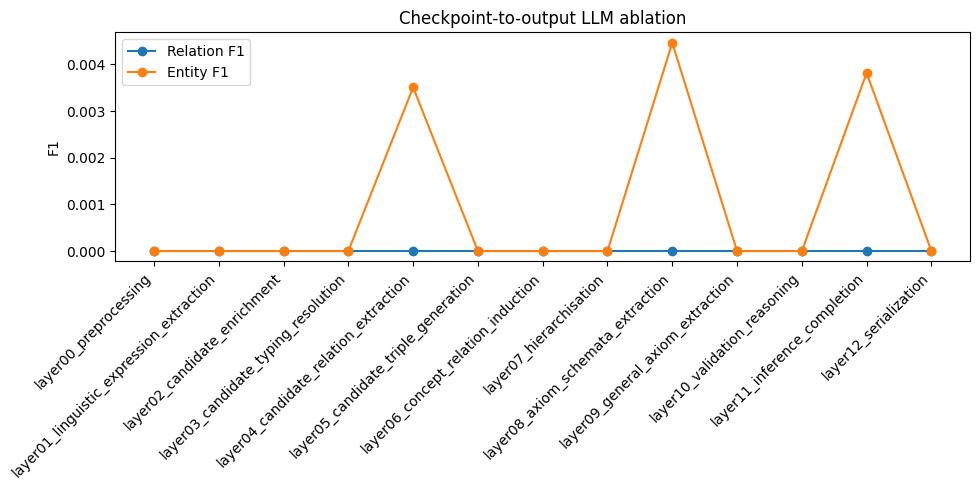

Saved plot: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\checkpoint_to_output_llm_ablation_batched_jsonl_robust\f1_by_checkpoint.png
Output directory: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\checkpoint_to_output_llm_ablation_batched_jsonl_robust
Main summary: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\checkpoint_to_output_llm_ablation_batched_jsonl_robust\summary_final.csv
Per-relation: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\checkpoint_to_output_llm_ablation_batched_jsonl_robust\per_relation_final.csv


In [13]:
# ============================================================
# 10. Final tables and plots
# ============================================================

per_rel_df = pd.DataFrame(all_per_relation_rows)
per_rel_df.to_csv(OUTPUT_DIR / "per_relation_final.csv", index=False)

display(summary_df)

try:
    import matplotlib.pyplot as plt

    plot_df = summary_df.copy()
    plot_df["x"] = range(len(plot_df))

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["x"], plot_df["relation_f1"], marker="o", label="Relation F1")
    plt.plot(plot_df["x"], plot_df["entity_f1"], marker="o", label="Entity F1")
    plt.xticks(plot_df["x"], plot_df["layer"], rotation=45, ha="right")
    plt.ylabel("F1")
    plt.title("Checkpoint-to-output LLM ablation")
    plt.legend()
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "f1_by_checkpoint.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved plot:", fig_path)
except Exception as e:
    print("Plot failed:", repr(e))

print("Output directory:", OUTPUT_DIR)
print("Main summary:", OUTPUT_DIR / "summary_final.csv")
print("Per-relation:", OUTPUT_DIR / "per_relation_final.csv")